# Práctica guiada: Procesamiento digital de imágenes

Esta práctica funciona como puente entre los cuadernos conceptuales y el laboratorio aplicado. La propuesta es que completes código, pruebes variantes y expliques con tus palabras qué decisiones tomaste.

## Objetivos

- Recuperar ideas de color, canales, bordes e intensidad.
- Practicar lectura de imágenes con `OpenCV`.
- Resolver consignas breves con andamiaje.
- Prepararte para el laboratorio de segmentación y la actividad integradora.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)
    if len(imagenes) == 1:
        axes = [axes]

    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        if imagen.ndim == 2:
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            ax.imshow(imagen)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def segmentar_por_umbral(imagen, umbral):
    mascara = np.zeros_like(imagen, dtype=np.uint8)
    mascara[imagen > umbral] = 255
    return mascara


In [2]:
base = Path(".")

cv2.imwrite(str(base / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))
cv2.imwrite(str(base / "texto.png"), ski.data.page())
cv2.imwrite(str(base / "monedas.png"), ski.data.coins())

print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")


Archivos de práctica listos: paisaje.png, texto.png y monedas.png


## Ejercicio 1: Color y canales

Completá los pasos.

1. Cargá `paisaje.png` con `OpenCV`.
2. Convertí la imagen a `RGB`.
3. Extraé los tres canales.
4. Mostrá la imagen original y los canales por separado.
5. Escribí una observación breve sobre qué zonas se destacan en cada canal.


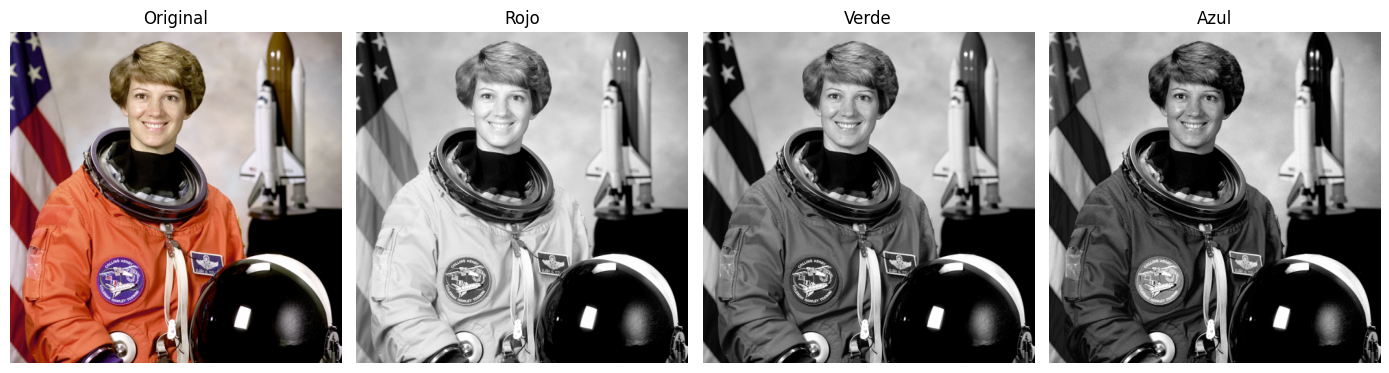

In [4]:
# 1. Cargar la imagen
img_bgr = cv2.imread("paisaje.png")

# 2. Convertirla a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Extraer canales
canal_rojo = img_rgb[:, :, 0]
canal_verde = img_rgb[:, :, 1]
canal_azul = img_rgb[:, :, 2]

# 4. Visualizar resultados
mostrar_imagenes( [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original", "Rojo", "Verde", "Azul"],
)


In [5]:
# Escribí acá tu observación sobre los canales.
# ¿Qué zonas aparecen más brillantes en cada uno?

observacion_canales = " En cada canal aparecen más brillantes las zonas donde hay presencia de esos colores."
print(observacion_canales)


 En cada canal aparecen más brillantes las zonas donde hay presencia de esos colores.


## Ejercicio 2: Recorte y redimensionado

1. Definí una región de interés de `100 x 100` píxeles dentro de `paisaje.png`.
2. Redimensioná ese recorte a `220 x 220` píxeles.
3. Armá un mosaico `2 x 2` con el recorte redimensionado.
4. Explicá, con una frase, la diferencia entre recortar y redimensionar.


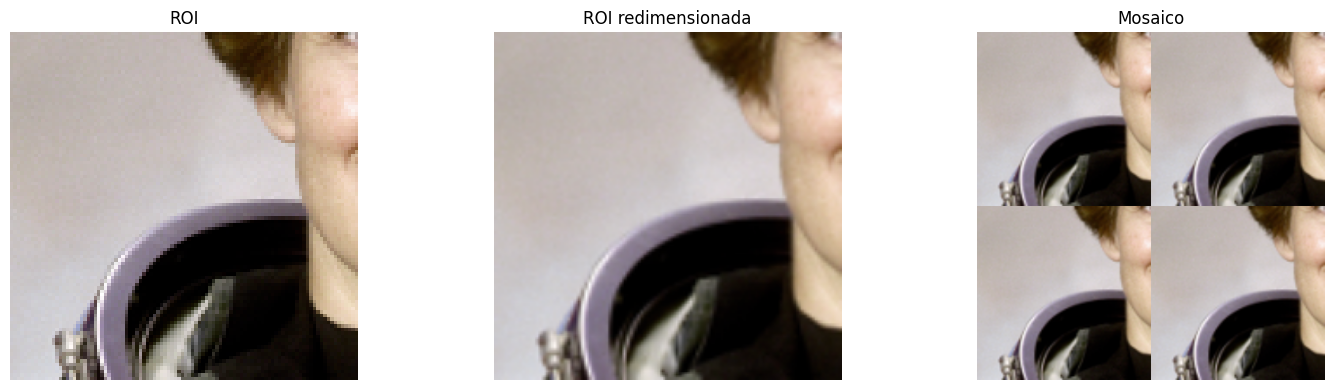

In [7]:
# Definí los índices de tu región de interés.
y1, y2 = 100,200
x1, x2 = 100,200

roi = img_rgb[y1:y2, x1:x2]
roi_grande = cv2.resize(roi, (220, 220))

# Armá un mosaico 2 x 2.
fila_superior = cv2.hconcat([roi_grande, roi_grande])
fila_inferior = cv2.hconcat([roi_grande, roi_grande])
mosaico = cv2.vconcat([fila_superior, fila_inferior])

mostrar_imagenes(
    [roi, roi_grande, mosaico],
    ["ROI", "ROI redimensionada", "Mosaico"],
    figsize=(15, 4),
)


In [8]:
# Explicación breve.
explicacion_geometria = "Recortar consiste en seleccionar una porción específica de la imagen y descartar el resto, mientras que redimensionar implica cambiar la escala o el tamaño digital (la cantidad de píxeles) de una imagen sin perder su contenido"
print(explicacion_geometria)


Recortar consiste en seleccionar una porción específica de la imagen y descartar el resto, mientras que redimensionar implica cambiar la escala o el tamaño digital (la cantidad de píxeles) de una imagen sin perder su contenido


## Ejercicio 3: Bordes y umbralización

1. Cargá `texto.png` en escala de grises.
2. Aplicá `Canny` con dos pares de umbrales distintos.
3. Cargá `monedas.png` en escala de grises.
4. Segmentá la imagen de monedas con al menos dos umbrales.
5. Compará los resultados y explicá cuál te parece más útil.


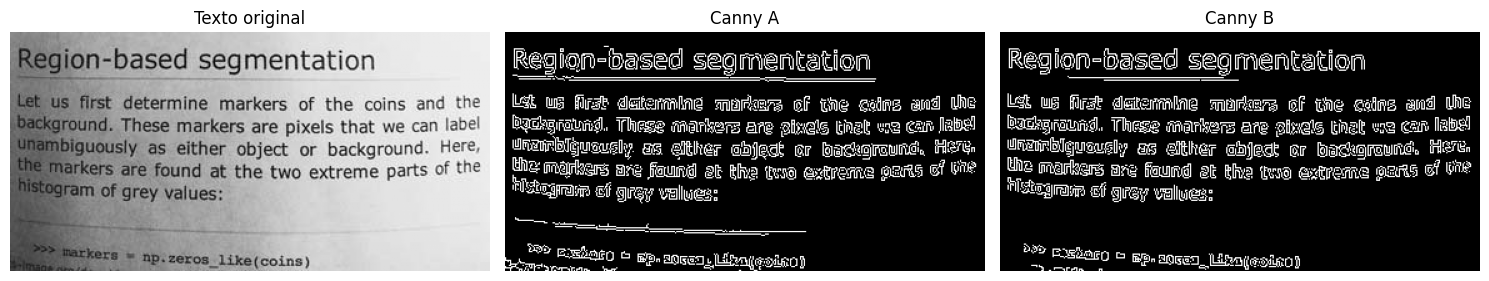

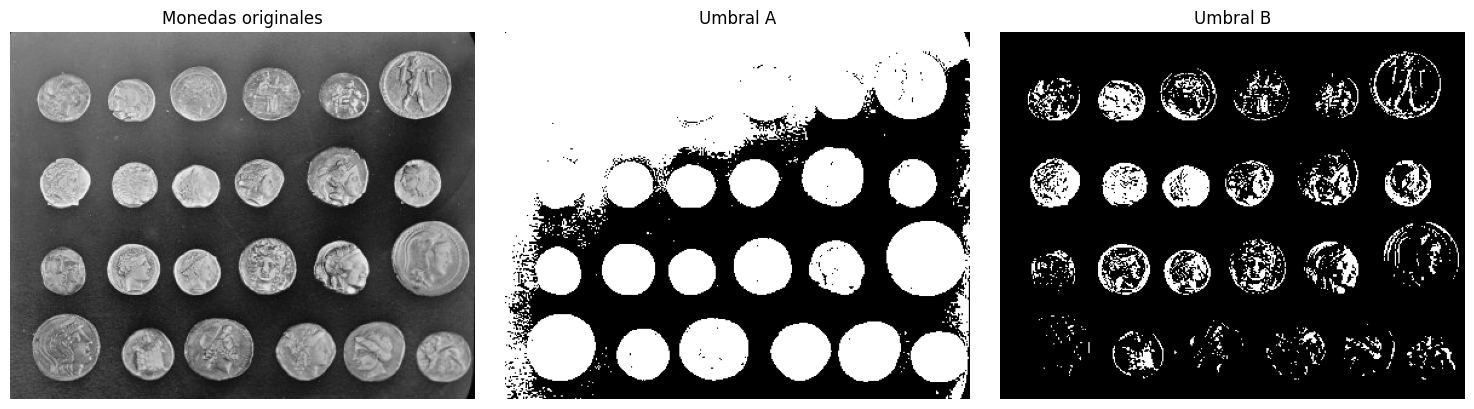

In [9]:
img_texto = cv2.imread("texto.png", cv2.IMREAD_GRAYSCALE)

canny_a = cv2.Canny(img_texto, 60, 120)
canny_b = cv2.Canny(img_texto, 140, 220)

mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A", "Canny B"],
    figsize=(15, 4),
)

img_monedas = cv2.imread("monedas.png", cv2.IMREAD_GRAYSCALE)

seg_a = segmentar_por_umbral(img_monedas, 70)
seg_b = segmentar_por_umbral(img_monedas, 175)

mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A", "Umbral B"],
    figsize=(15, 4),
)


## Cierre breve

Antes de pasar al laboratorio, revisá si podés responder estas preguntas:

- ¿cuándo conviene mirar canales por separado?

Conviene al trabajar con imágenes a color y el objeto que se quiere aislar tiene un color predominante. Separar los canales (R, G, B o HSV) nos permite elegir el canal que ofrezca el mayor contraste entre el objeto y el fondo antes de binarizar.

- ¿qué cambia al modificar los umbrales de `Canny`?

Lo que cambia es la sensibilidad del algoritmo ante los cambios de intensidad. Con umbrales más bajos el algoritmo es más sensible; detecta bordes sutiles pero arrastra ruido o gradientes suaves. Con umbrales más altos, Se vuelve más estricto; elimina ese ruido de fondo pero puede hacer que los bordes reales se vuelvan discontinuos o se pierdan.

- ¿por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra?

Porque el umbral global básico depende críticamente de que la iluminación sea uniforme y el contraste sea neto.

En el ejemplo de las monedas, la imagen original tiene un gradiente de luz (está más iluminada arriba a la derecha). Por eso, un umbral bajo (Umbral A) quema el fondo confundiéndolo con las monedas, y un umbral alto (Umbral B) solo detecta los brillos internos dejando las monedas "huecas".

Si todavía dudás en alguna, volvé a los cuadernos anteriores y recuperá las ideas centrales.
